# Домашнее задание №2

рынок: Франция <br>
период: 2023 год

Гайфиев Иван, <br>
Цирулёв Дмитрий, <br>
Прокопец Артём,<br>
23КНТ-6

### Задание 1: Efficient frontier.
Выбрать на рынке набор из 50 акций. Объясните ваш выбор (целью является
построение портфеля инвестиций из выбранных активов). Построить эффективный фронт портфелей
инвестиций без ограничений на короткие позиции и эффективный фронт с запретом коротких
позиций. Сравнить эффективные фронты и сделать выводы. При построении эффективных фронтов
вычислить портфели с минимальным риском и отметить их на соответствующем эффективном
фронте. Рассмотреть портфель с равными долями вложения капитала и оценить, как далек этот
портфель от эффективного фронта. Тот же вопрос для индекса рынка.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import seaborn as sns
from sklearn import decomposition


In [3]:
# Функция для "умного" чтения ваших файлов
def load_and_clean(filename):
    df = pd.read_csv(filename, sep=';')
    # Берем только первые 10 символов даты (01.01.2023) и конвертируем
    df.iloc[:, 0] = df.iloc[:, 0].astype(str).str.extract(r'(\d{2}\.\d{2}\.\d{4})')[0]
    df['Date'] = pd.to_datetime(df.iloc[:, 0], dayfirst=True, errors='coerce')
    df = df.set_index('Date').dropna(how='all')
    
    # Превращаем строки с запятыми в числа
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.replace(',', '.').astype(float)
    return df.select_dtypes(include=[np.number])

# 1. Загрузка данных
print("Загрузка данных...")
stocks_df = load_and_clean("french_stocks_50.csv") # 50 акций
market_df = load_and_clean("CAC40.csv")            # Индекс CAC40

# 2. Расчет доходностей (Log Returns)
# Для акций
returns_50 = np.log(stocks_df / stocks_df.shift(1)).dropna()
# Для индекса (берем первую колонку)
market_ret = np.log(market_df.iloc[:, 0] / market_df.iloc[:, 0].shift(1)).dropna()

# 3. Сбор общей статистики (stock_stat) как в примере
# Создаем DataFrame для хранения E (доходность) и Sigma (риск) каждой акции
stock_stat = pd.DataFrame(columns=['symbol', 'E', 'Sigma', 'mean_vol'])

for symbol in returns_50.columns:
    stock_stat.loc[symbol] = [
        symbol,
        returns_50[symbol].mean(),
        returns_50[symbol].std(),
        1000 # Ставим условный объем, так как в файле его нет (нужно для размера точек на графике)
    ]

print(f"Готово! Обработано активов: {len(stock_stat)}")
stock_stat.head()

Загрузка данных...
Готово! Обработано активов: 50


,symbol,E,Sigma,mean_vol
Stellantis NV,Stellantis NV,0.002070,0.015907,1000
DNXcorp SA,DNXcorp SA,0.003373,0.026997,1000
IDI,IDI,0.001373,0.012187,1000
Credit Agricole,Credit Agricole,0.001356,0.012047,1000
Accor,Accor,0.001598,0.014464,1000


In [4]:
def get_return_mean_cov(returns_df): 
    """Получить матрицу доходностей, вектор средних и матрицу ковариации"""
    r_matrix = returns_df.values
    mean_vec = returns_df.mean().values
    cov_matrix = returns_df.cov().values
    return r_matrix, mean_vec, cov_matrix

def plot_mean_var_map(df, x='Sigma', y='E', title='Карта активов: σ от E', figsize=(12, 6)):
    """Рисует карту всех акций"""
    # Размер точек фиксируем, т.к. реального Volume нет
    ax = df.plot(x=x, y=y, kind='scatter', s=50, 
                 figsize=figsize, edgecolor='black', grid=True)
    plt.xlabel('Sigma (Риск)', size=12)
    plt.ylabel('E (Доходность)', size=12)
    plt.title(title, size=14)

# --- Функции оптимизации (из примера) ---

def risk_porfolio(X, cov_matrix, n_observations=1, sqrt=True):
    # риск портфеля
    if sqrt:
        return np.sqrt(np.dot(np.dot(X, cov_matrix), X.T))
    else:
        return np.dot(np.dot(X, cov_matrix), X.T) / np.sqrt(n_observations)

def optimize_portfolio(risk_porfolio, returns, mean_returns, cov_matrix, bounds, target_return=None):
    # Оптимизатор SLSQP
    X = np.ones(returns.shape[1])
    X = X / X.sum() # Равные доли для старта
    
    constraints = [{'type': 'eq', 'fun': lambda X: np.sum(X) - 1.0}]
    
    if target_return is not None:
        constraints.append({'type': 'eq', 
                            'fun': lambda X: np.dot(X, mean_returns) - target_return})

    result = minimize(risk_porfolio, X,
                    args=(cov_matrix,), 
                    method='SLSQP',
                    constraints=constraints,
                    bounds=bounds)
    return result.x

print("Функции оптимизации инициализированы.")

Функции оптимизации инициализированы.


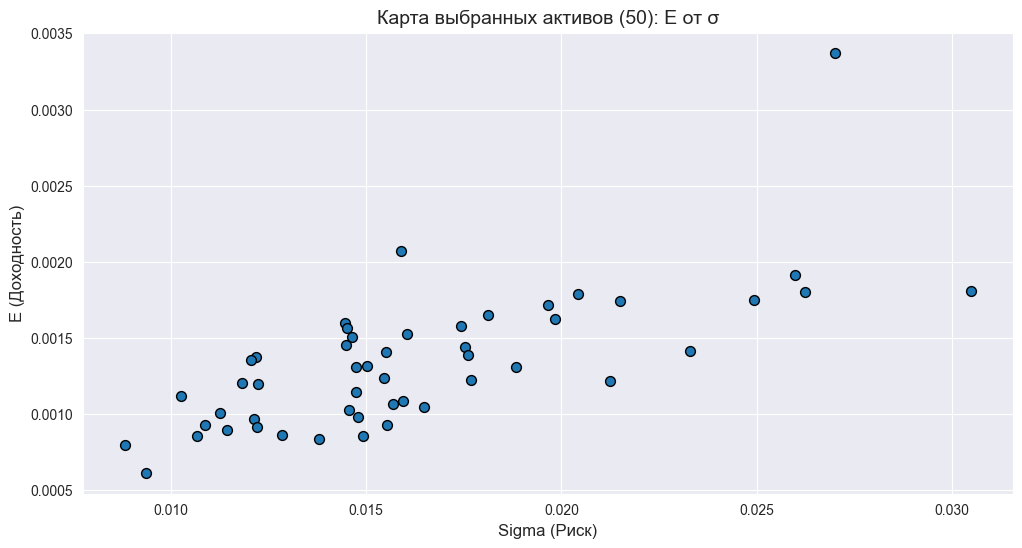

Запуск расчета фронта с шортами...
Запуск расчета фронта без шортов...
Все расчеты завершены!


In [5]:
# 1. Визуализация карты активов
plot_mean_var_map(stock_stat, title='Карта выбранных активов (50): E от σ')
plt.show()

# Подготовка данных для оптимизатора
r_matrix, mean_vec, cov_matrix = get_return_mean_cov(returns_50)

# --- А) Эффективный фронт БЕЗ ограничений на шорты (Shorts Allowed) ---
print("Запуск расчета фронта с шортами...")
psigmas = []
preturns = []
bounds_short = tuple((None, None) for _ in range(len(mean_vec)))

# Портфель мин. риска
X_min_risk = optimize_portfolio(risk_porfolio, r_matrix, mean_vec, cov_matrix, bounds_short)
min_risk = risk_porfolio(X_min_risk, cov_matrix)
min_risk_preturn = np.dot(X_min_risk, mean_vec)

# Цикл расчета целевых доходностей
target_range = np.linspace(min_risk_preturn, mean_vec.max(), 50)
for tr in target_range:
    X = optimize_portfolio(risk_porfolio, r_matrix, mean_vec, cov_matrix, bounds_short, target_return=tr)
    psigmas.append(risk_porfolio(X, cov_matrix))
    preturns.append(np.dot(X, mean_vec))

# --- Б) Эффективный фронт С ЗАПРЕТОМ шортов (No Shorts) ---
print("Запуск расчета фронта без шортов...")
psigmas_ns = []
preturns_ns = []
bounds_no_short = tuple((0.0, 1.0) for _ in range(len(mean_vec)))

# Портфель мин. риска без шортов
X_min_risk_ns = optimize_portfolio(risk_porfolio, r_matrix, mean_vec, cov_matrix, bounds_no_short)
min_risk_ns = risk_porfolio(X_min_risk_ns, cov_matrix)
min_risk_preturn_ns = np.dot(X_min_risk_ns, mean_vec)

# Цикл расчета
target_range_ns = np.linspace(min_risk_preturn_ns, mean_vec.max(), 50)
for tr in target_range_ns:
    X_ns = optimize_portfolio(risk_porfolio, r_matrix, mean_vec, cov_matrix, bounds_no_short, target_return=tr)
    psigmas_ns.append(risk_porfolio(X_ns, cov_matrix))
    preturns_ns.append(np.dot(X_ns, mean_vec))

print("Все расчеты завершены!")

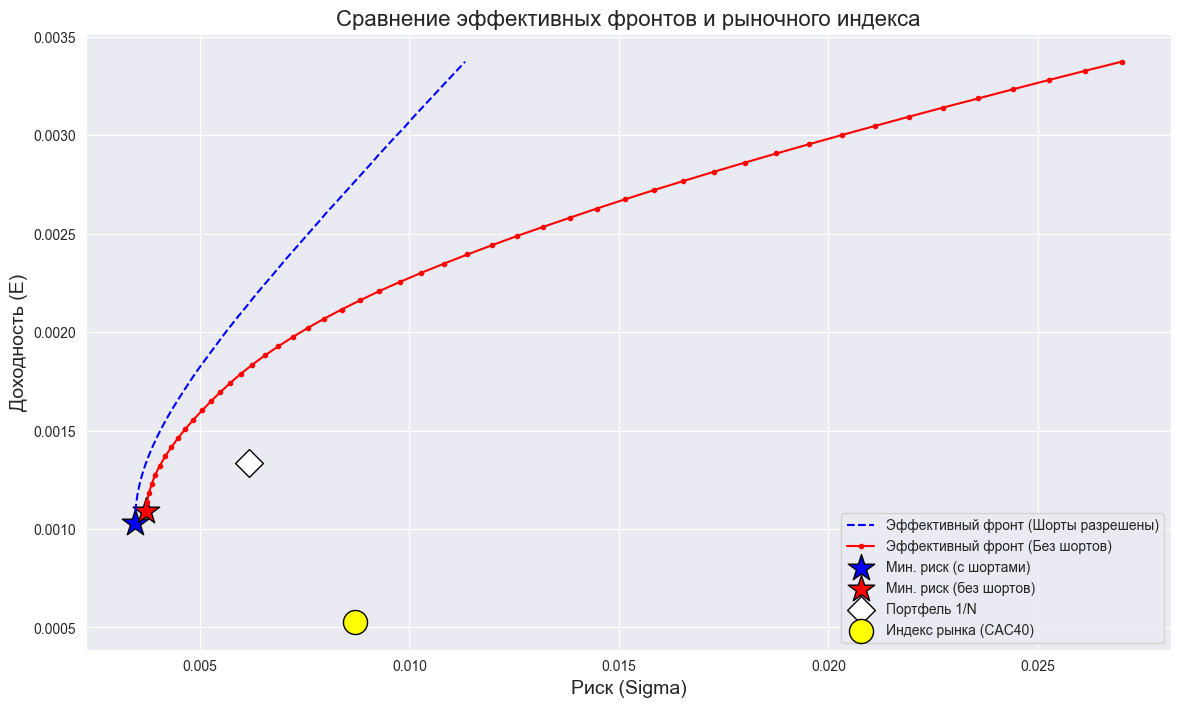

Выводы:
1. Фронт без шортов (красный) всегда лежит внутри или ниже синего фронта.
2. Рыночный портфель имеет риск 0.0087 и доходность 0.0005.


In [6]:
plt.figure(figsize=(14, 8))

# 1. Фронты
plt.plot(psigmas, preturns, 'b--', label='Эффективный фронт (Шорты разрешены)')
plt.plot(psigmas_ns, preturns_ns, 'r.-', label='Эффективный фронт (Без шортов)')

# 2. Точки минимального риска
plt.scatter(min_risk, min_risk_preturn, c='blue', marker='*', s=400, edgecolors='black', 
            label='Мин. риск (с шортами)')
plt.scatter(min_risk_ns, min_risk_preturn_ns, c='red', marker='*', s=400, edgecolors='black', 
            label='Мин. риск (без шортов)')

# 3. Портфель с равными долями (1/N)
weights_equal = np.ones(len(mean_vec)) / len(mean_vec)
risk_equal = risk_porfolio(weights_equal, cov_matrix)
return_equal = np.dot(weights_equal, mean_vec)

plt.scatter(risk_equal, return_equal, c='white', marker='D', s=200, edgecolors='black', 
            label='Портфель 1/N')

# 4. Индекс рынка (CAC40)
sigma_market = market_ret.std()
mean_market = market_ret.mean()

plt.scatter(sigma_market, mean_market, c='yellow', marker='o', s=300, edgecolors='black', 
            label='Индекс рынка (CAC40)')

plt.title('Сравнение эффективных фронтов и рыночного индекса', size=16)
plt.xlabel('Риск (Sigma)', size=14)
plt.ylabel('Доходность (E)', size=14)
plt.legend()
plt.grid(True)
plt.show()

print("Выводы:")
print("1. Фронт без шортов (красный) всегда лежит внутри или ниже синего фронта.")
print(f"2. Рыночный портфель имеет риск {sigma_market:.4f} и доходность {mean_market:.4f}.")

### Задание 2: Portfolio selection problem.
Требуется построить «хорошие» инвестиционные портфели из 10
активов вместо исходных 50 (или даже всех активов рынка). Предложите способ выбрать 10 активов
(из отобранных ранее 50) для формирования портфеля. Сравните эффективные фронты всего набора
(50 акций) и выбранного набора активов (10 акций) для двух случаев
- короткие продажи разрешены,
- короткие продажи запрещены.
Если результат сравнения показывает, что выбор 10 активов не очень удачный, подумайте, как
сделать лучший выбор.

### Задание 3: Risk aversion.
Оцените свое отношение к риску и постройте свой личный оптимальный портфель
инвестиций из выбранных 50 активов. Дайте характеристику портфеля по составу и долям активов.
Оцените VaR и CVaR портфеля. Сделайте выводы. Рассмотрите два случая:
- короткие продажи разрешены,
- короткие продажи запрещены.

### Задание 4: Markowitz-Tobin model.
Рассмотрите набор активов, отобранных в п.2 (10 активов). Выберете
безрисковый актив (можно виртуальный). Постройте рыночный (оптимальный) портфель. Сделайте
анализ долей активов рыночного портфеля. Оцените VaR и CVaR портфеля. Сделайте выводы.
Рассмотрите два случая:
- короткие продажи разрешены,
- короткие продажи запрещены.

###Задание 5: One factor model.
Рассмотрите набор активов, отобранных в п.2 (10 активов). Проверьте
выполнение условий модели с одним фактором, выбрав в качестве фактора индекс рынка. Считая
модель адекватной найдите рыночный портфель для этого набора активов (воспользуйтесь формулой
весов оптимального портфеля в модели с одним фактором). Сравните его с портфелем п.4.

### Индекс рынка.
Разберитесь, как составляется портфель индекса (определите веса, с которыми
активы входят в индекс). Дайте характеристику индекса (гистограмма, распределение, выбросы).
Найдите собственные значения матрицы ковариаций активов индекса. Что необычного в
распределении собственных значений? На основе метода главных компонент предложите свою
модель индекса рынка. Сравните ваш индекс с индексом рынка.

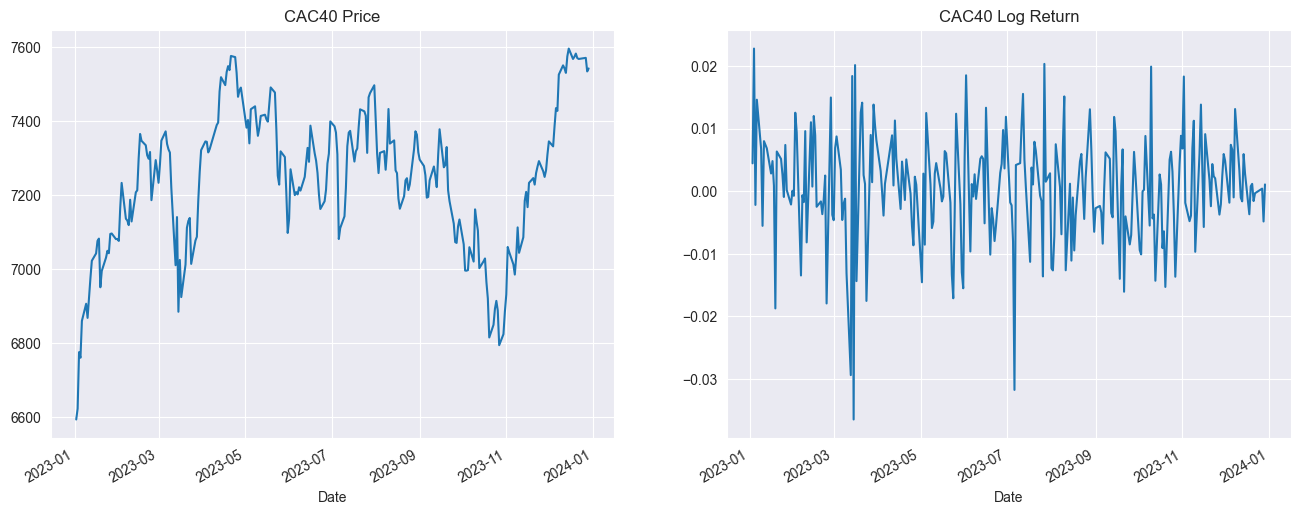

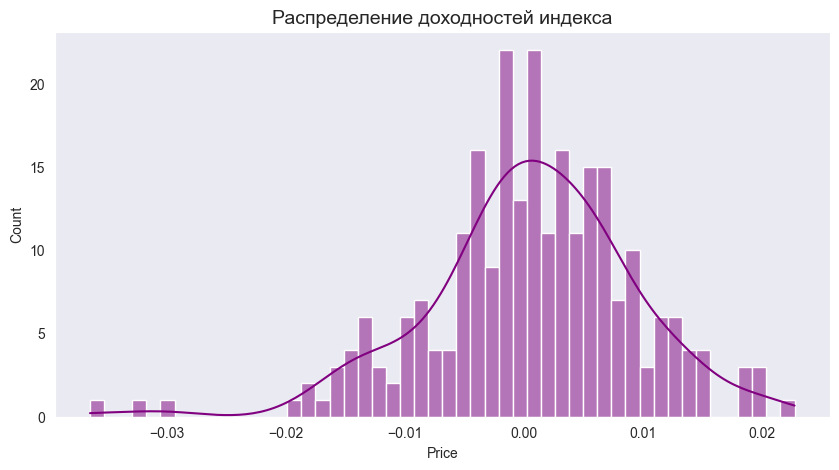

Объясненная дисперсия первыми 4 компонентами: [0.17888571 0.06388387 0.05739782 0.0499828 ]
Суммарно: 35.02%


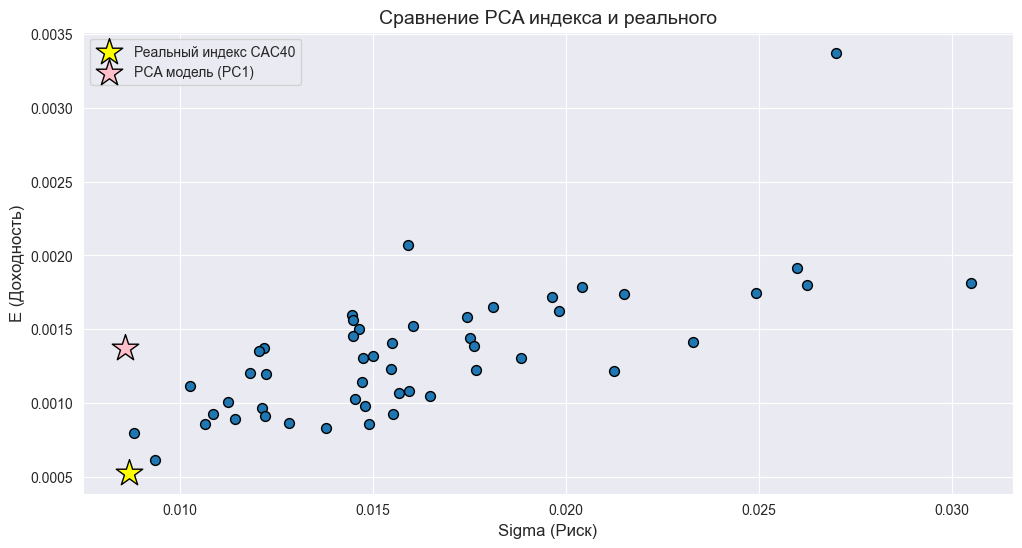

In [7]:
# 1. Графики индекса
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
market_df.iloc[:, 0].plot(grid=True, title='CAC40 Price')
plt.subplot(1, 2, 2)
market_ret.plot(grid=True, title='CAC40 Log Return')
plt.show()

# 2. Гистограмма распределения
plt.figure(figsize=(10, 5))
sns.histplot(market_ret, bins=50, kde=True, color='purple')
plt.title('Распределение доходностей индекса', size=14)
plt.grid()
plt.show()

# 3. PCA Моделирование
pca = decomposition.PCA(n_components=4)
pca.fit(r_matrix)

# Вклад компонент
print(f"Объясненная дисперсия первыми 4 компонентами: {pca.explained_variance_ratio_}")
print(f"Суммарно: {sum(pca.explained_variance_ratio_):.2%}")

# Берем 1-ю компоненту (это и есть "Рынок")
weights_pca = pca.components_[0]
weights_pca = weights_pca / sum(weights_pca) # Нормируем, чтобы сумма была 1

# Считаем параметры PCA-портфеля
pca_risk = risk_porfolio(weights_pca, cov_matrix)
pca_return = np.dot(weights_pca, mean_vec)

# Отображаем на карте
plot_mean_var_map(stock_stat, title='Сравнение PCA индекса и реального')
plt.scatter(sigma_market, mean_market, c='yellow', marker='*', s=400, edgecolors='black', label='Реальный индекс CAC40')
plt.scatter(pca_risk, pca_return, c='pink', marker='*', s=400, edgecolors='black', label='PCA модель (PC1)')
plt.legend()
plt.show()